<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/Benchmark_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocess datasets (UNR-IDD and Edge-IIoTset) and Train CatBoost Models

## Edge-IIoTset

In [94]:
import pandas as pd
from sklearn.utils import shuffle

# Load Edge-IIoTset
df = pd.read_csv('/content/drive/MyDrive/IRP/Comp Datasets/Edge-IoTset/ML-EdgeIIoT-dataset.csv', low_memory=False)

In [5]:
print(df.columns)

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len

In [6]:
print(len(df.columns))

63


In [7]:
print(df['Attack_label'].unique())

[1 0]


In [8]:
print(df['Attack_type'].unique())

['MITM' 'Fingerprinting' 'Ransomware' 'Uploading' 'SQL_injection'
 'DDoS_HTTP' 'DDoS_TCP' 'Password' 'Port_Scanning' 'Vulnerability_scanner'
 'Backdoor' 'XSS' 'Normal' 'DDoS_UDP' 'DDoS_ICMP']


In [13]:
print(df['Attack_type'].value_counts())

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64


<Axes: xlabel='Attack_type'>

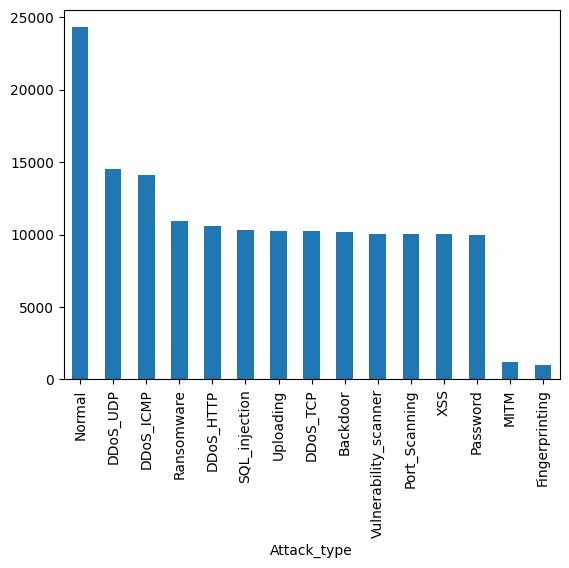

In [14]:
df['Attack_type'].value_counts().plot(kind='bar')

In [9]:
df.head()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [95]:
# Remove IPs/Ports/Timestamps that cause fake accuracy.
drop_columns = [
    "frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4",
    "arp.dst.proto_ipv4", "http.file_data", "http.request.full_uri",
    "icmp.transmit_timestamp", "http.request.uri.query", "tcp.options",
    "tcp.payload", "tcp.srcport", "tcp.dstport", "udp.port", "mqtt.msg"
]
df.drop(columns=[c for c in drop_columns if c in df.columns], axis=1, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [96]:
df = shuffle(df).reset_index(drop=True)
df.to_csv('/content/drive/MyDrive/IRP/Comp Datasets/Edge-IoTset/NT-Clean-ML-EdgeIIoT-dataset.csv', index=False)

In [28]:
from sklearn.preprocessing import LabelEncoder

# Identify object (string) columns
object_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove 'Attack_type' from this list so we don't encode the label by mistake
if 'Attack_type' in object_cols:
    object_cols.remove('Attack_type')

print(f"Transforming columns to binary/numeric: {object_cols}")

# Option A: Simple Label Encoding (Best for CatBoost/Trees)
le = LabelEncoder()
for col in object_cols:
    df[col] = le.fit_transform(df[col].astype(str))

Transforming columns to binary/numeric: ['http.request.method', 'http.referer', 'http.request.version', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']


In [30]:
df = shuffle(df).reset_index(drop=True)
df.to_csv('cleaned_EdgeIIoT.csv', index=False)

In [23]:
print(df.dtypes)

arp.opcode                   float64
arp.hw.size                  float64
icmp.checksum                float64
icmp.seq_le                  float64
icmp.unused                  float64
http.content_length          float64
http.request.method           object
http.referer                  object
http.request.version          object
http.response                float64
http.tls_port                float64
tcp.ack                      float64
tcp.ack_raw                  float64
tcp.checksum                 float64
tcp.connection.fin           float64
tcp.connection.rst           float64
tcp.connection.syn           float64
tcp.connection.synack        float64
tcp.flags                    float64
tcp.flags.ack                float64
tcp.len                      float64
tcp.seq                      float64
udp.stream                   float64
udp.time_delta               float64
dns.qry.name                 float64
dns.qry.name.len              object
dns.qry.qu                   float64
d

## UNR-IDD

In [101]:
import pandas as pd
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

train_df = pd.read_csv('/content/drive/MyDrive/IRP/Comp Datasets/UNR-IDD/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/IRP/Comp Datasets/UNR-IDD/test.csv')
valid_df = pd.read_csv('/content/drive/MyDrive/IRP/Comp Datasets/UNR-IDD/val.csv')

UNR_IDD = pd.concat([train_df, test_df, valid_df], axis=0, ignore_index=True)

In [81]:
UNR_IDD.head()

,Switch ID,Port Number,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Delta Received Packets,Delta Received Bytes,Delta Sent Bytes,...,Connection Point,Total Load/Rate,Total Load/Latest,Unknown Load/Rate,Unknown Load/Latest,Latest bytes counter,Active Flow Entries,Packets Looked Up,Packets Matched,Label
0,of:0000000000000004,Port#:1,240,16586,12622603,467,126,0,0,280,...,1,0,0,0,0,0,4,819,757,TCP-SYN
1,of:0000000000000004,Port#:2,158,20530,35464,376,171,4,556,3407,...,2,0,0,0,0,0,5,1018,918,TCP-SYN
2,of:0000000000000008,Port#:3,1930,37881404,67857371,414333,1297,0,0,556,...,2,0,0,0,0,0,8,987400,987276,Normal
3,of:0000000000000001,Port#:4,903,18946410,17900326,98088,176,3,320,270280,...,3,0,0,0,0,0,8,195879,195780,PortScan
4,of:000000000000000b,Port#:1,423,29020,19138042,1562,1451,0,0,560,...,1,0,0,0,0,0,4,4524,4411,Overflow


In [82]:
print(UNR_IDD.dtypes)

Switch ID                        object
Port Number                      object
Received Packets                  int64
Received Bytes                    int64
Sent Bytes                        int64
Sent Packets                      int64
Port alive Duration (S)           int64
Delta Received Packets            int64
Delta Received Bytes              int64
Delta Sent Bytes                  int64
Delta Sent Packets                int64
Delta Port alive Duration (S)     int64
Connection Point                  int64
Total Load/Rate                   int64
Total Load/Latest                 int64
Unknown Load/Rate                 int64
Unknown Load/Latest               int64
Latest bytes counter              int64
Active Flow Entries               int64
Packets Looked Up                 int64
Packets Matched                   int64
Label                            object
dtype: object


<Axes: xlabel='Label'>

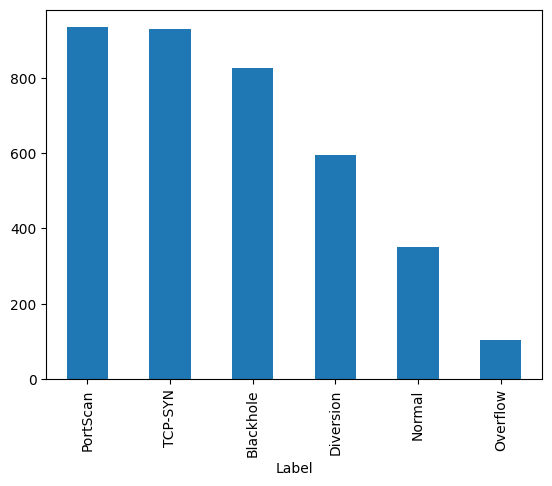

In [83]:
UNR_IDD['Label'].value_counts().plot(kind='bar')

In [89]:
print(len(UNR_IDD))

3741


In [102]:
UNR_IDD = UNR_IDD.drop(['Switch ID', 'Port Number'], axis=1)

# 3. Clean Missing Data & Duplicates
UNR_IDD.dropna(inplace=True)
UNR_IDD.drop_duplicates(inplace=True)

In [104]:
import numpy as np

UNR_IDD['Attack'] = np.where(UNR_IDD['Label'] == 'Normal', 0, 1)

In [106]:
UNR_IDD = shuffle(UNR_IDD).reset_index(drop=True)
UNR_IDD.to_csv('/content/drive/MyDrive/IRP/Comp Datasets/UNR-IDD/NT_cleaned_UNR-IDD.csv', index=False)

In [107]:
UNR_IDD.dtypes

,0
Received Packets,int64
Received Bytes,int64
Sent Bytes,int64
Sent Packets,int64
Port alive Duration (S),int64
Delta Received Packets,int64
Delta Received Bytes,int64
Delta Sent Bytes,int64
Delta Sent Packets,int64
Delta Port alive Duration (S),int64


## Train & Save Models

In [16]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.3 MB/s eta 0:00:00


In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import brier_score_loss
import time
from sklearn.metrics import brier_score_loss
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, confusion_matrix

In [97]:
#### cleaned_EdgeIIoT_retrain #####

import pandas as pd
SDN_train_test_data = pd.read_csv("/content/cleaned_EdgeIIoT.csv")
def scale_data(data):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    return scaled_data
SDN_scaled_data = scale_data(SDN_train_test_data.drop(columns=['Attack_type', 'Attack_label']))
def split_data(data, labels, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test
data_train, data_test, labels_train, labels_test = split_data(SDN_scaled_data, SDN_train_test_data['Attack_label'])

In [108]:
#### UNR-IDD #####

SDN_train_test_data = pd.read_csv("/content/drive/MyDrive/IRP/Comp Datasets/UNR-IDD/NT_cleaned_UNR-IDD.csv")
SDN_scaled_data = scale_data(SDN_train_test_data.drop(columns=['Label','Attack']))
data_train, data_test, labels_train, labels_test = split_data(SDN_scaled_data, SDN_train_test_data['Attack'])

In [33]:
def train_and_evaluate_models(model, data_train, labels_train, data_test, labels_test):
  # Training Time
  start_train = time.time()
  model.fit(data_train, labels_train)
  end_train = time.time()
  training_duration = end_train - start_train

  # Inference Time
  start_inf = time.time()
  preds = model.predict(data_test)
  end_inf = time.time()
  inference_duration = (end_inf - start_inf) / len(data_test) # Average per packet

  probs = model.predict_proba(data_test)[:, 1]
  bs = brier_score_loss(labels_test, probs)

  return preds, training_duration, inference_duration,bs

In [34]:
def plot_confusion_matrix(model, model_name, data_test, labels_test, preds):
  fig, ax = plt.subplots(figsize=(8, 6))
  ConfusionMatrixDisplay.from_predictions(labels_test, preds,
                                          display_labels=["Normal", "Attack"],
                                          cmap="Blues", ax=ax)
  plt.title(f"Confusion Matrix for {model_name}")
  plt.show()

  tn, fp, fn, tp = confusion_matrix(labels_test, preds).ravel()

  # Calculate FPR and FNR
  fpr = fp / (fp + tn)
  fnr = fn / (fn + tp)

  print(f"False Positive Rate (FPR): {fpr:.4f}")
  print(f"False Negative Rate (FNR): {fnr:.4f}")
  return fpr, fnr

------------------------------------------------------------
CATBoost Results:
Overall Accuracy: 99.15%
Brier Score: 0.0085
Training Time: 0.03 seconds
Inference Time: 0.0000010007 seconds per packet
------------------------------------------------------------
Classification Report:
{'0': {'precision': 1.0, 'recall': 0.946321243523316, 'f1-score': 0.9724204025130444, 'support': 4825.0}, '1': {'precision': 0.9899899513024658, 'recall': 1.0, 'f1-score': 0.9949697993746237, 'support': 25615.0}, 'accuracy': 0.991491458607096, 'macro avg': {'precision': 0.9949949756512328, 'recall': 0.973160621761658, 'f1-score': 0.983695100943834, 'support': 30440.0}, 'weighted avg': {'precision': 0.9915766295207838, 'recall': 0.991491458607096, 'f1-score': 0.9913955273688051, 'support': 30440.0}}


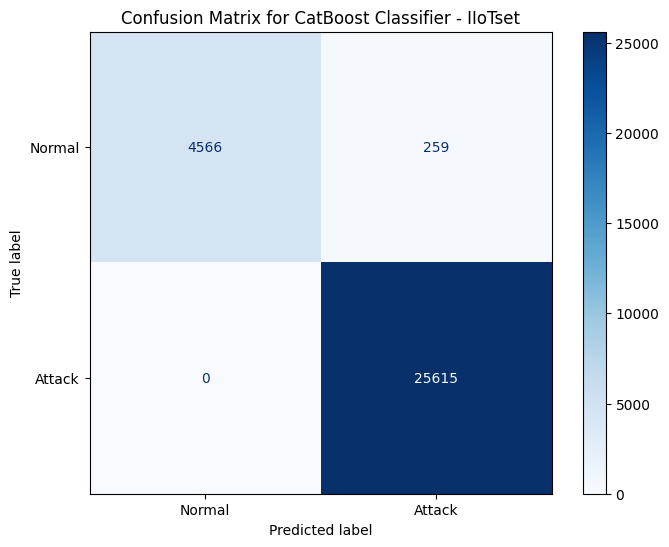

False Positive Rate (FPR): 0.0537
False Negative Rate (FNR): 0.0000


In [99]:
# Initialize CatBoost
# similar parameters to your XGBoost setup for a fair comparison
cat_model_IIoTset = CatBoostClassifier(iterations=1, depth=1, learning_rate=0.1, verbose=0)

preds, training_duration_cat, inference_duration_cat,bs_cat = train_and_evaluate_models(cat_model_IIoTset, data_train[:100], labels_train[:100], data_test, labels_test)
accuracy_cat = accuracy_score(labels_test, preds)

print("-" * 60)
print("CATBoost Results:")
print(f"Overall Accuracy: {accuracy_cat * 100:.2f}%")
print(f"Brier Score: {bs_cat:.4f}")
print(f"Training Time: {training_duration_cat:.2f} seconds")
print(f"Inference Time: {inference_duration_cat:.10f} seconds per packet")
print("-" * 60)

print("Classification Report:")
report = classification_report(labels_test, preds, output_dict=True)
print(report)

fpr_cat,fnr_cat = plot_confusion_matrix(cat_model_IIoTset, "CatBoost Classifier - IIoTset", data_test, labels_test, preds)

------------------------------------------------------------
CATBoost Results:
Overall Accuracy: 95.33%
Brier Score: 0.2228
Training Time: 0.02 seconds
Inference Time: 0.0000012729 seconds per packet
------------------------------------------------------------
Classification Report:
{'0': {'precision': 0.7678571428571429, 'recall': 0.6615384615384615, 'f1-score': 0.7107438016528925, 'support': 65.0}, '1': {'precision': 0.9682539682539683, 'recall': 0.9809941520467836, 'f1-score': 0.9745824255628177, 'support': 684.0}, 'accuracy': 0.9532710280373832, 'macro avg': {'precision': 0.8680555555555556, 'recall': 0.8212663067926226, 'f1-score': 0.8426631136078551, 'support': 749.0}, 'weighted avg': {'precision': 0.950863055502575, 'recall': 0.9532710280373832, 'f1-score': 0.9516858827668965, 'support': 749.0}}


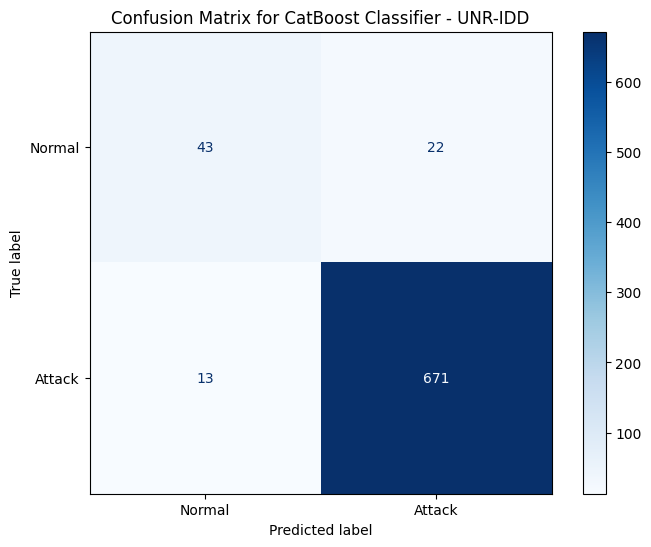

False Positive Rate (FPR): 0.3385
False Negative Rate (FNR): 0.0190


In [134]:
# Initialize CatBoost
# similar parameters to your XGBoost setup for a fair comparison
cat_model_UNR_IDD = CatBoostClassifier(iterations=1, depth=1, learning_rate=0.1, verbose=0)

preds, training_duration_cat, inference_duration_cat,bs_cat = train_and_evaluate_models(cat_model_UNR_IDD, data_train[:40], labels_train[:40], data_test, labels_test)
accuracy_cat = accuracy_score(labels_test, preds)

print("-" * 60)
print("CATBoost Results:")
print(f"Overall Accuracy: {accuracy_cat * 100:.2f}%")
print(f"Brier Score: {bs_cat:.4f}")
print(f"Training Time: {training_duration_cat:.2f} seconds")
print(f"Inference Time: {inference_duration_cat:.10f} seconds per packet")
print("-" * 60)

print("Classification Report:")
report = classification_report(labels_test, preds, output_dict=True)
print(report)

fpr_cat,fnr_cat = plot_confusion_matrix(cat_model_UNR_IDD, "CatBoost Classifier - UNR-IDD", data_test, labels_test, preds)

## Save Models and data splits

In [136]:
from google.colab import drive
import os
import joblib
from datetime import datetime

drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/IRP_Models/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Saving Models
cat_filename = f'catboost_UNR_IDD_{timestamp}.cbm'
cat_model_IIoTset.save_model(os.path.join(save_path, cat_filename))
print(f"CatBoost saved as: {cat_filename}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CatBoost saved as: catboost_UNR_IDD_20260225_073008.cbm


In [135]:
import joblib
import os

split_path = '/content/drive/MyDrive/IRP_Models/Data_Splits/UNR-IDD/'
if not os.path.exists(split_path):
    os.makedirs(split_path)

joblib.dump(data_train, f'{split_path}X_train.pkl')
joblib.dump(data_test, f'{split_path}X_test.pkl')
joblib.dump(labels_train, f'{split_path}y_train.pkl')
joblib.dump(labels_test, f'{split_path}y_test.pkl')

print(f"Data splits successfully saved!")

Data splits successfully saved!
